### PRIZMO Tutorial

In [1]:
from pyprizmo import Prizmo
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


### Carbon collisional ionization network

In [ ]:
network = '''
C + E -> C+ + E + E                      [] 6.850000e-08 * 1e0 / (1.930000e-01 + 1.130000e+01 * invTe) * 1.833452e+00 * invTe**(0.25) * exp(-11.30 * invTe)

C+ + E -> C                              [] 4.700000e-13 / Tgas14**(0.62)

# these dummy species are necessary because of internal structure of the code, but they are not used in the network
DUMMY{H, H2, H+, CO, O, O+}
'''


### First preprocessor instance

In [3]:
# NOTE: energy limits are here for later use
prizmo = Prizmo(network_text=network, arguments={"energy_minmax": [6.0, 13.6]})

******************
CHEMISTRY
Reading chemical network: ../networks/temp_network_66271.dat
Adding dummy species: H, H2, H+, CO, O, O+
******************
ATOMIC COOLING
C H
C H2or
C H2pa
C H+
C e
O H
O H2or
O H2pa
O H+
O e
C+ e
C+ H
C+ H2pa
C+ H2or
O+ e
******************
PHOTOCHEMISTRY
Calculate Verner cross sections for  C__C+_E
11.26 13.6
Calculate Verner cross sections for  C+__C++_E
13.6 24.38
Calculate Verner cross sections for  H__H+_E
13.599999999999998 13.6
Calculate Verner cross sections for  O__O+_E
13.6 13.62
Calculate Verner cross sections for  O+__O++_E
13.6 35.12
radiation field range, eV 6.000000000000001 13.6
field: baspec_lx30.dat@2.04e30@5e2-5e3
Habing flux: 1.2735813109215445e-18 11 999
******************
DUST OPACITY


100%|██████████| 1000/1000 [00:03<00:00, 296.83it/s]


kabs integral 912-1100 AA: 61582.51560874997
******************
DUST TEMPERATURE AND COOLING
4*Bint/h, (min/max) 7.39846642980523e-21 4.017275987070075e+22


100%|██████████| 100/100 [03:35<00:00,  2.16s/it]


******************
SHIELDING H2
******************
SHIELDING CO
******************
H2 COOLING
******************
CR HEATING
******************
HEATING HEADER
******************
COOLING HEADER
******************
MAIN
************************
Number of chemical species: 9
idx_C = 1
idx_CO = 2
idx_Cj = 3
idx_E = 4
idx_H = 5
idx_H2 = 6
idx_Hj = 7
idx_O = 8
idx_Oj = 9
(note: indexes are 1-based)
************************
All preprocessing done!
/home/tgrassi/repos/prizmo
rm -f *.o *.mod *__genmod.f90 *~ *.i90 *.i test libprizmo_18485c10410b4defaa205d3dcc51c7c9.so libprizmo.so
ifx -O3 -g -traceback -xHost -fp-model=precise -fpp -fPIC -shared -c opkda1.f -o opkda1.o  -nowarn
ifx -O3 -g -traceback -xHost -fp-model=precise -fpp -fPIC -shared -c opkda2.f -o opkda2.o  -nowarn
ifx -O3 -g -traceback -xHost -fp-model=precise -fpp -fPIC -shared -c opkdmain.f -o opkdmain.o  -nowarn
ifx -O3 -g -traceback -xHost -fp-model=precise -fpp -fPIC -shared -c prizmo_fit_types.f90 -o prizmo_fit_types.o 
ifx -O3 -

### Compute chemistry at different temperatures

In [4]:
nspecies = prizmo.nspecies
nphoto = prizmo.nphoto

# convert year to second
seconds_per_year = 365. * 24 * 3600

def compute_tgas_range():
    xall = []
    tgas_range = np.logspace(3, 6, 100)
    # abundances in cm^-3
    for Tgas in tqdm(tgas_range):
        x = np.zeros(nspecies)
        x[prizmo.species2index("C+")] = 0.5  # C+
        x[prizmo.species2index("E")] = 0.5   # e-

        x *= 1e4  # total density of 1e4 cm^-3

        jflux = np.zeros(nphoto)  # no radiation field
        dt = 1e5 * seconds_per_year # time step, s

        x, Tgas = prizmo.evolve(x, Tgas, jflux, dt, solve_thermo=False)
        xall.append(x.copy())

    return tgas_range, np.array(xall)

tgas_range, xall = compute_tgas_range()

print(tgas_range.shape, xall.shape)


100%|██████████| 100/100 [00:00<00:00, 2934.29it/s]

(100,) (100, 9)


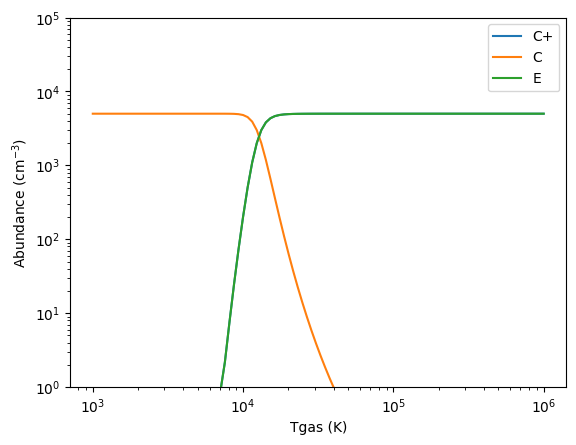

In [5]:

def plot_species(tgas_range, xall, species):
    for sp in species:
        plt.plot(tgas_range, xall[:, prizmo.species2index(sp)], label=sp)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Tgas (K)")
    plt.ylabel("Abundance (cm$^{-3}$)")
    plt.ylim(1e0, 1e5)
    plt.legend()
    plt.show()

plot_species(tgas_range, xall, ["C+", "C", "E"])

### Additional ionization levels

In [ ]:
network = '''
C + E -> C+ + E + E                      [] 6.850000e-08 * 1e0 / (1.930000e-01 + 1.130000e+01 * invTe) * 1.833452e+00 * invTe**(0.25) * exp(-11.30 * invTe)
C+ + E -> C++ + E + E                    [] 1.860000e-08 * (1e0 + 4.939636e+00 * invsqrTe) / (2.860000e-01 + 2.440000e+01 * invTe) * 2.152651e+00 * invTe**(0.24) * exp(-24.40 * invTe)
C++ + E -> C+++ + E + E                  [] 6.350000e-09 * (1e0 + 6.920983e+00 * invsqrTe) / (4.270000e-01 + 4.790000e+01 * invTe) * 2.253567e+00 * invTe**(0.21) * exp(-47.90 * invTe)
C+++ + E -> C++++ + E + E                [] 1.500000e-09 * (1e0 + 8.031189e+00 * invsqrTe) / (4.160000e-01 + 6.450000e+01 * invTe) * 1.718869e+00 * invTe**(0.13) * exp(-64.50 * invTe)

C+ + E -> C                              [] 4.700000e-13 / Tgas14**(0.62)
C++ + E -> C+                            [] 2.300000e-12 / Tgas14**(0.65)
C+++ + E -> C++                          [] 4.900000e-12 / Tgas14**(0.80)
C++++ + E -> C+++                        [] 1.912274e-09 * invsqrTgas / ((1e0 + 4.465888e-02 * sqrTgas)**(0.48) * (1e0 + 2.600255e-04 * sqrTgas)**(1.52))

DUMMY{H, H2, H+, CO, O, O+}
'''

prizmo = Prizmo(network_text=network)


******************
CHEMISTRY
Reading chemical network: ../networks/temp_network_310347.dat
Adding dummy species: H, H2, H+, CO, O, O+
******************
ATOMIC COOLING
C H
C H2or
C H2pa
C H+
C e
O H
O H2or
O H2pa
O H+
O e
C+ e
C+ H
C+ H2pa
C+ H2or
O+ e
******************
PHOTOCHEMISTRY
Calculate Verner cross sections for  C__C+_E
11.26 10000.0
Calculate Verner cross sections for  C+__C++_E
24.38 10000.0
Calculate Verner cross sections for  C++__C+++_E
47.89 10000.0
Calculate Verner cross sections for  C+++__C++++_E
64.49 10000.0
Calculate Verner cross sections for  C++++__C+++++_E
392.1 10000.0
Calculate Verner cross sections for  H__H+_E
13.6 10000.0
Calculate Verner cross sections for  O__O+_E
13.62 10000.0
Calculate Verner cross sections for  O+__O++_E
35.12 10000.0
radiation field range, eV 0.01 10000.0
field: baspec_lx30.dat@2.04e30@5e2-5e3
Habing flux: 1.2735950340900436e-18 464 523
******************
DUST OPACITY
kabs integral 912-1100 AA: 60746.71463393077
******************
DU

100%|██████████| 100/100 [00:01<00:00, 98.91it/s]


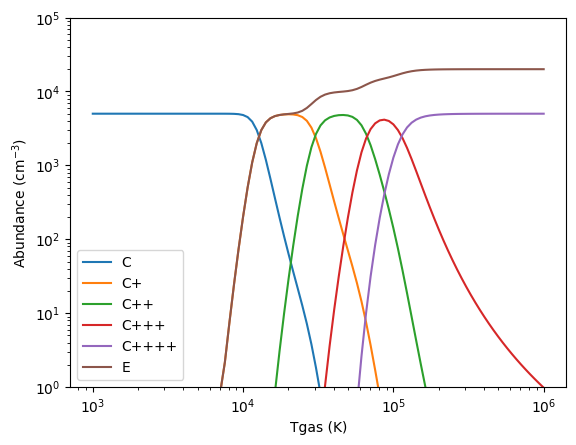

In [7]:
tgas_range, xall = compute_tgas_range()
plot_species(tgas_range, xall, ["C", "C+", "C++", "C+++", "C++++", "E"])

### Introducing cosmic rays ionization

In [ ]:
network = '''
C + E -> C+ + E + E                      [] 6.850000e-08 * 1e0 / (1.930000e-01 + 1.130000e+01 * invTe) * 1.833452e+00 * invTe**(0.25) * exp(-11.30 * invTe)
C+ + E -> C++ + E + E                    [] 1.860000e-08 * (1e0 + 4.939636e+00 * invsqrTe) / (2.860000e-01 + 2.440000e+01 * invTe) * 2.152651e+00 * invTe**(0.24) * exp(-24.40 * invTe)
C++ + E -> C+++ + E + E                  [] 6.350000e-09 * (1e0 + 6.920983e+00 * invsqrTe) / (4.270000e-01 + 4.790000e+01 * invTe) * 2.253567e+00 * invTe**(0.21) * exp(-47.90 * invTe)
C+++ + E -> C++++ + E + E                [] 1.500000e-09 * (1e0 + 8.031189e+00 * invsqrTe) / (4.160000e-01 + 6.450000e+01 * invTe) * 1.718869e+00 * invTe**(0.13) * exp(-64.50 * invTe)

C+ + E -> C                              [] 4.700000e-13 / Tgas14**(0.62)
C++ + E -> C+                            [] 2.300000e-12 / Tgas14**(0.65)
C+++ + E -> C++                          [] 4.900000e-12 / Tgas14**(0.80)
C++++ + E -> C+++                        [] 1.912274e-09 * invsqrTgas / ((1e0 + 4.465888e-02 * sqrTgas)**(0.48) * (1e0 + 2.600255e-04 * sqrTgas)**(1.52))

C -> C+ + E                              [] 2.6e2 * user_cr

DUMMY{H, H2, H+, CO, O, O+}
'''

prizmo = Prizmo(network_text=network)


******************
CHEMISTRY
Reading chemical network: ../networks/temp_network_443857.dat
Adding dummy species: H, H2, H+, CO, O, O+
******************
ATOMIC COOLING
C H
C H2or
C H2pa
C H+
C e
O H
O H2or
O H2pa
O H+
O e
C+ e
C+ H
C+ H2pa
C+ H2or
O+ e
******************
PHOTOCHEMISTRY
Calculate Verner cross sections for  C__C+_E
11.26 10000.0
Calculate Verner cross sections for  C+__C++_E
24.38 10000.0
Calculate Verner cross sections for  C++__C+++_E
47.89 10000.0
Calculate Verner cross sections for  C+++__C++++_E
64.49 10000.0
Calculate Verner cross sections for  C++++__C+++++_E
392.1 10000.0
Calculate Verner cross sections for  H__H+_E
13.6 10000.0
Calculate Verner cross sections for  O__O+_E
13.62 10000.0
Calculate Verner cross sections for  O+__O++_E
35.12 10000.0
radiation field range, eV 0.01 10000.0
field: baspec_lx30.dat@2.04e30@5e2-5e3
Habing flux: 1.2735950340900436e-18 464 523
******************
DUST OPACITY
kabs integral 912-1100 AA: 60746.71463393077
******************
DU

### Evolve chemistry at different cosmic rays ionization rates

In [9]:

nspecies = prizmo.nspecies
nphoto = prizmo.nphoto

seconds_per_year = 365. * 24 * 3600

xall = []
cr_range = np.logspace(-17, -14, 100)
# abundances in cm^-3
for cr in tqdm(cr_range):
    x = np.zeros(nspecies)
    x[prizmo.species2index("C+")] = 1e-4  # C+
    x[prizmo.species2index("E")] = 1e-4   # e-

    x *= 1e3  # total density of 1e4 cm^-3

    jflux = np.zeros(nphoto)  # no radiation field
    dt = 1e6 * seconds_per_year # time step, s
    Tgas = 1e3

    prizmo.set_crate(cr)

    x, Tgas = prizmo.evolve(x, Tgas, jflux, dt, solve_thermo=False)
    xall.append(x.copy())

xall = np.array(xall)


100%|██████████| 100/100 [00:00<00:00, 3472.62it/s]


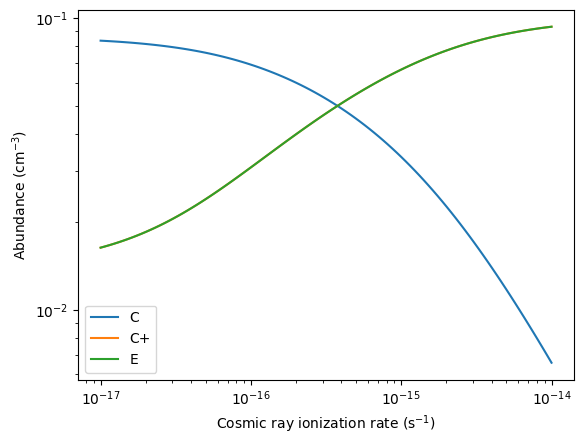

In [10]:
for sp in ["C", "C+", "E"]:
    plt.plot(cr_range, xall[:, prizmo.species2index(sp)], label=sp)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Cosmic ray ionization rate (s$^{-1}$)")
plt.ylabel("Abundance (cm$^{-3}$)")
plt.legend()
plt.show()

### Introducing photoionization

In [ ]:
network = '''
C + E -> C+ + E + E         [] 6.850000e-08 * 1e0 / (1.930000e-01 + 1.130000e+01 * invTe) * 1.833452e+00 * invTe**(0.25) * exp(-11.30 * invTe)
C+ + E -> C++ + E + E       [] 1.860000e-08 * (1e0 + 4.939636e+00 * invsqrTe) / (2.860000e-01 + 2.440000e+01 * invTe) * 2.152651e+00 * invTe**(0.24) * exp(-24.40 * invTe)
C++ + E -> C+++ + E + E     [] 6.350000e-09 * (1e0 + 6.920983e+00 * invsqrTe) / (4.270000e-01 + 4.790000e+01 * invTe) * 2.253567e+00 * invTe**(0.21) * exp(-47.90 * invTe)
C+++ + E -> C++++ + E + E   [] 1.500000e-09 * (1e0 + 8.031189e+00 * invsqrTe) / (4.160000e-01 + 6.450000e+01 * invTe) * 1.718869e+00 * invTe**(0.13) * exp(-64.50 * invTe)

C+ + E -> C                 [] 4.700000e-13 / Tgas14**(0.62)
C++ + E -> C+               [] 2.300000e-12 / Tgas14**(0.65)
C+++ + E -> C++             [] 4.900000e-12 / Tgas14**(0.80)
C++++ + E -> C+++           [] 1.912274e-09 * invsqrTgas / ((1e0 + 4.465888e-02 * sqrTgas)**(0.48) * (1e0 + 2.600255e-04 * sqrTgas)**(1.52))

C -> C+ + E                 [] 2.6e2 * user_cr
C -> C+ + E                 [] PHOTO, 11.2603


DUMMY{H, H2, H+, CO, O, O+}
'''

prizmo = Prizmo(network_text=network, arguments={"energy_minmax": [6.0, 13.6]})


******************
CHEMISTRY
Reading chemical network: ../networks/temp_network_353803.dat
Adding dummy species: H, H2, H+, CO, O, O+
******************
ATOMIC COOLING
C H
C H2or
C H2pa
C H+
C e
O H
O H2or
O H2pa
O H+
O e
C+ e
C+ H
C+ H2pa
C+ H2or
O+ e
******************
PHOTOCHEMISTRY
Calculate Verner cross sections for  C__C+_E
11.26 13.6
Calculate Verner cross sections for  C+__C++_E
13.6 24.38
Calculate Verner cross sections for  C++__C+++_E
13.6 47.89
Calculate Verner cross sections for  C+++__C++++_E
13.6 64.49
Calculate Verner cross sections for  C++++__C+++++_E
13.6 392.1
Calculate Verner cross sections for  H__H+_E
13.599999999999998 13.6
Calculate Verner cross sections for  O__O+_E
13.6 13.62
Calculate Verner cross sections for  O+__O++_E
13.6 35.12
radiation field range, eV 6.000000000000001 13.6
field: baspec_lx30.dat@2.04e30@5e2-5e3
Habing flux: 1.273581311092105e-18 11 999
******************
DUST OPACITY
kabs integral 912-1100 AA: 61523.61133336858
******************
DUST

In [12]:
erg2ev = 6.24150647996e11  # erg -> eV
hplanck_eV = 4.135667696e-15  # eV*s

def get_draine_field(energy):
    energy_ev = energy * erg2ev
    bfield = (1.658e6 * energy_ev - 2.152e5 * energy_ev**2 + 6.919e3 * energy_ev**3) * hplanck_eV * energy_ev / erg2ev
    return bfield * ((energy_ev >= 6e0) & (energy_ev <= 13.6)).astype(float)


### Solving for different FUV values

In [13]:

nspecies = prizmo.nspecies
seconds_per_year = 365. * 24 * 3600

xall = []
jscale_range = np.logspace(-2, 3, 100)
# abundances in cm^-3
for jscale in tqdm(jscale_range):
    x = np.zeros(nspecies)
    x[prizmo.species2index("H")] = 1.
    x[prizmo.species2index("C+")] = 1e-4  # C+
    x[prizmo.species2index("E")] = 1e-4   # e-

    x *= 1e6  # total density of 1e4 cm^-3

    jflux = get_draine_field(prizmo.energy) * jscale
    dt = 1e5 * seconds_per_year # time step, s
    Tgas = 1e3

    prizmo.set_crate(2e-17)

    x, Tgas = prizmo.evolve(x, Tgas, jflux, dt, solve_thermo=False)
    xall.append(x.copy())

xall = np.array(xall)



100%|██████████| 100/100 [00:00<00:00, 2388.96it/s]


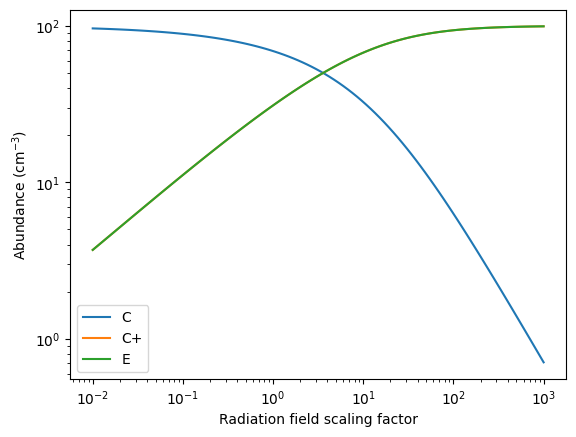

In [14]:
for sp in ["C", "C+", "E"]:
    plt.plot(jscale_range, xall[:, prizmo.species2index(sp)], label=sp)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Radiation field scaling factor")
plt.ylabel("Abundance (cm$^{-3}$)")
plt.legend()
plt.show()


### A larger chemical network

In [ ]:
prizmo = Prizmo(arguments={"chemNet": "../networks/network_approx.dat",
                           "energy_minmax": [6.0, 13.6]})

******************
CHEMISTRY
Reading chemical network: ../networks/network_approx.dat
Adding dummy species: 
******************
ATOMIC COOLING
C H
C H2or
C H2pa
C H+
C e
O H
O H2or
O H2pa
O H+
O e
C+ e
C+ H
C+ H2pa
C+ H2or
O+ e
******************
PHOTOCHEMISTRY
Calculate Verner cross sections for  C__C+_E
11.26 13.6
Calculate Verner cross sections for  C+__C++_E
13.6 24.38
Calculate Verner cross sections for  H__H+_E
13.599999999999998 13.6
Calculate Verner cross sections for  He__He+_E
13.6 24.59
Calculate Verner cross sections for  He+__He++_E
13.6 54.42
Calculate Verner cross sections for  O__O+_E
13.6 13.62
Calculate Verner cross sections for  O+__O++_E
13.6 35.12
radiation field range, eV 6.000000000000001 13.6
field: baspec_lx30.dat@2.04e30@5e2-5e3
Habing flux: 1.2735813112577485e-18 11 998
******************
DUST OPACITY
kabs integral 912-1100 AA: 61484.69073596468
******************
DUST TEMPERATURE AND COOLING
skipping, tdust grid file found ../runtime_data/tdust_grid.dat
****

### Evolving the chemistry and temperature (cooling and heating)

In [16]:
nspecies = prizmo.nspecies
nphoto = prizmo.nphoto
sp2idx = prizmo.species2index

# convert year to second
seconds_per_year = 365. * 24 * 3600

# abundances in cm^-3
x = np.zeros(nspecies)
x[sp2idx("C+")] = 1e-4  # C+
x[sp2idx("E")] = 1e-4   # e-
x[sp2idx("H2")] = 1e0  # H2
x[sp2idx("O")] = 2e-4   # O

# scale to total number density of 1e4 cm^-3
x *= 1e4

Tgas = 1e3 # gas temperature in K
jflux = get_draine_field(prizmo.energy)  # negligible radiation field

dt = 1e-1 * seconds_per_year  # initial time, s
tend = 1e8 * seconds_per_year # end time, s

# arrays to store results
all_x = []
all_tgas = []
tt = []

# initial time, s
t = 0e0

# loop to evolve the chemistry
while True:
    # increase the timestep
    dt = min(dt*1.3, tend-t)

    # evolve the chemistry
    x, Tgas = prizmo.evolve(x, Tgas, jflux, dt)

    # increase total time
    t += dt

    # store data
    all_x.append(x.copy())
    all_tgas.append(Tgas)
    tt.append(t)

    # break when time limit is reached
    if t >= tend:
        break

# convert lists to numpy arrays for easier handling
all_x = np.array(all_x)
all_tgas = np.array(all_tgas)
tt = np.array(tt)

print(all_x.shape, tt.shape)

(74, 33) (74,)


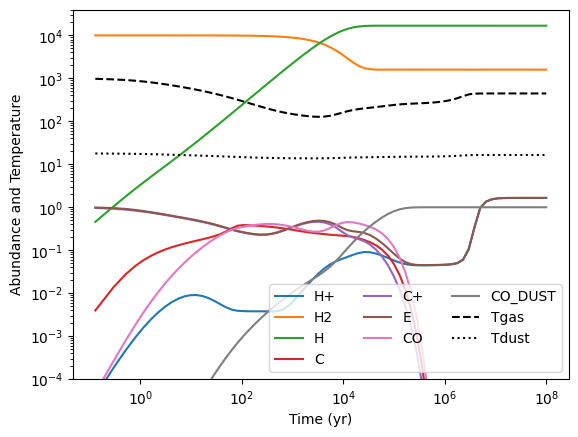

In [17]:

all_tdust = np.array([prizmo.get_tdust(x, tgas, jflux) for x, tgas in zip(all_x, all_tgas)])
#colors = plt.cm.tab20.colors

labels = ["H+", "H2", "H", "C", "C+", "E", "CO", "CO_DUST"]
for i, lab in enumerate(labels):
    what = all_x[:, sp2idx(lab)]
    plt.plot(tt / seconds_per_year, what, label=lab)#, color=colors[i % len(colors)])
plt.plot(tt / seconds_per_year, all_tgas, label='Tgas', color='k', linestyle='--')
plt.plot(tt / seconds_per_year, all_tdust, label='Tdust', color='k', linestyle=':')

plt.ylim(1e-4, 4e4)
plt.xlabel('Time (yr)')
plt.ylabel('Abundance and Temperature')
plt.legend(ncols=3)
plt.xscale('log')
plt.yscale('log')


### Show cooling and heating contributions

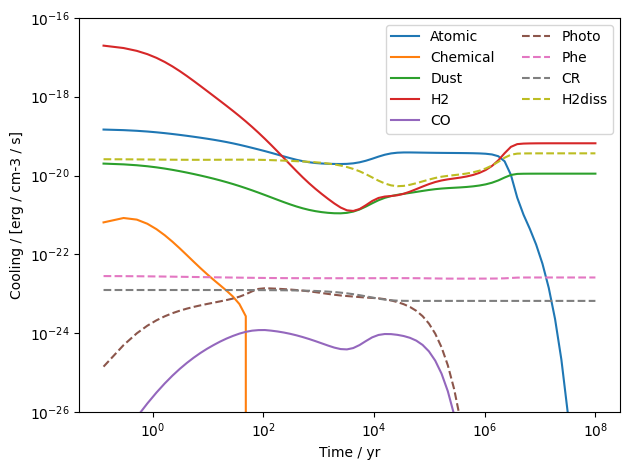

In [18]:
# compute cooling at every time-step
cool = np.array([prizmo.get_cooling_array(all_x[i], all_tgas[i], jflux) for i in range(len(all_tgas))])
# compute heating at every time-step
heat = np.array([prizmo.get_heating_array(all_x[i], all_tgas[i], jflux) for i in range(len(all_tgas))])

# plot cooling terms as a function of time
labels = ["Atomic", "Chemical", "Dust", "H2", "CO"]

for i, lab in enumerate(labels):
    plt.plot(tt / seconds_per_year, cool[:, i], label=lab)

# plot cooling terms as a function of time
labels = ["Photo", "Phe", "CR", "H2diss"]
for i, lab in enumerate(labels):
    plt.plot(tt / seconds_per_year, heat[:, i], label=lab, ls='--')

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Time / yr")
plt.ylabel("Cooling / [erg / cm-3 / s]")
plt.ylim(1e-26, 1e-16)
plt.legend(ncols=2)
plt.tight_layout()
plt.show()

### Radiative transfer

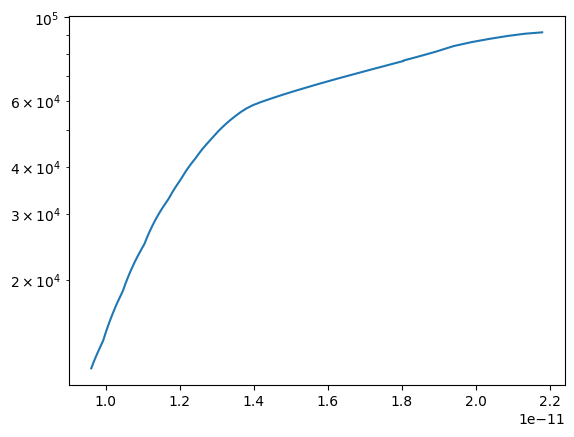

In [19]:
plt.plot(prizmo.energy, prizmo.dust_opacity)
#plt.xscale("log")
plt.yscale("log")
plt.show()

In [20]:
jflux = get_draine_field(prizmo.energy)  # negligible radiation field
